In [1]:
import sys, os
try:
    _d = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _d = os.getcwd()
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, '_config.yml')): break
    _d = os.path.dirname(_d)
if _d not in sys.path: sys.path.insert(0, _d)
from ai_widget_loader import load_ai_widget
load_ai_widget()

# שימוש ב־Pandas יחד עם Matplotlib ו־NumPy

Pandas נוחה מאוד לארגון ולבחירה של נתונים, אבל לעיתים נרצה להשתמש בספריות אחרות על אותם נתונים. בדוגמה זו נראה שני חיבורים חשובים:

- שימוש ב־Matplotlib כדי להציג שאלה כימית בצורה גרפית.
- המרה של עמודות Pandas למערכי NumPy בעזרת `.to_numpy()`.

```{note}
אפשר להוריד את קובץ הנתונים לעבודה עצמאית: {download}`compound_phase_points.csv <files/compound_phase_points.csv>`.
```


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.max_rows = 20

df = pd.read_csv("files/compound_phase_points.csv")
display(df)


,compound,formula,family,molar_mass_g_mol,melting_point_C,boiling_point_C,polarity
0,water,H2O,inorganic,18.02,0.0,100.0,polar
1,methanol,CH4O,alcohol,32.04,-97.6,64.7,polar
2,ethanol,C2H6O,alcohol,46.07,-114.1,78.4,polar
3,1-propanol,C3H8O,alcohol,60.10,-126.0,97.2,polar
4,acetone,C3H6O,ketone,58.08,-94.7,56.1,polar
5,diethyl ether,C4H10O,ether,74.12,-116.3,34.6,weakly polar
6,hexane,C6H14,alkane,86.18,-95.0,68.7,nonpolar
7,heptane,C7H16,alkane,100.20,-90.6,98.4,nonpolar
8,benzene,C6H6,aromatic,78.11,5.5,80.1,nonpolar
9,toluene,C7H8,aromatic,92.14,-95.0,110.6,nonpolar


## גרף עמודות: אילו חומרים רותחים גבוה יותר?

כאשר רוצים להשוות ערך מספרי בין קטגוריות, גרף עמודות הוא בחירה טבעית. כאן כל קטגוריה היא תרכובת, והערך הוא נקודת הרתיחה שלה.

שימו לב שהשורה `sort_values` בהמשך **לא מסננת** חומרים מהטבלה. היא רק משנה את סדר השורות, כך שהתרכובות יוצגו מהרתיחה הנמוכה ביותר לגבוהה ביותר. כל התרכובות שנמצאות ב־`df` מופיעות בגרף.


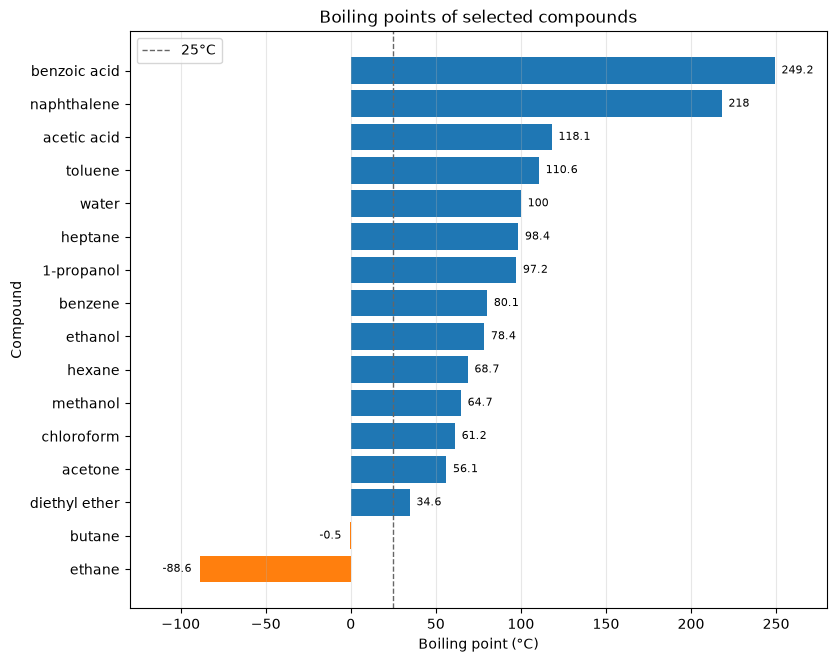

In [3]:
boiling_sorted = df.sort_values("boiling_point_C")
bar_colors = np.where(boiling_sorted["boiling_point_C"] < 25, "tab:orange", "tab:blue")

fig, ax = plt.subplots(figsize=(9, 7.5))
ax.barh(boiling_sorted["compound"], boiling_sorted["boiling_point_C"], color=bar_colors)
ax.axvline(25, color="0.4", linestyle="--", linewidth=1, label="25°C")

for compound, boiling in zip(boiling_sorted["compound"], boiling_sorted["boiling_point_C"]):
    if boiling >= 0:
        x_text = boiling + 4
        ha = "left"
    else:
        x_text = boiling - 5
        ha = "right"
    ax.text(x_text, compound, f"{boiling:g}", va="center", ha=ha, fontsize=8)

ax.set_xlim(-130, 280)
ax.set_xlabel("Boiling point (°C)")
ax.set_ylabel("Compound")
ax.set_title("Boiling points of selected compounds")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.show()


הסידור לפי נקודת הרתיחה מקל על הקריאה: אפשר לראות מיד ש־diethyl ether רותח בטמפרטורה נמוכה יחסית, וש־acetic acid נמצאת בקצה הגבוה של הטבלה. זהו שימוש טוב בגרף: הוא עונה על שאלה אחת ברורה.


## המרה למערכי NumPy

פונקציות רבות במדע חישובי מקבלות מערכי NumPy. עמודת Pandas היא `Series`, ואפשר להמיר אותה למערך בעזרת `.to_numpy()`. כאן נשתמש בשתי עמודות מספריות שיש להן משמעות כימית ברורה: נקודת ההתכה ונקודת הרתיחה.


In [4]:
melting_point = df["melting_point_C"].to_numpy()
boiling_point = df["boiling_point_C"].to_numpy()
compound_names = df["compound"].to_numpy()

print(type(melting_point))
print(compound_names)
print(melting_point)
print(boiling_point)


<class 'numpy.ndarray'>
['water' 'methanol' 'ethanol' '1-propanol' 'acetone' 'diethyl ether'
 'hexane' 'heptane' 'benzene' 'toluene' 'acetic acid' 'chloroform'
 'ethane' 'butane' 'naphthalene' 'benzoic acid']
[   0.   -97.6 -114.1 -126.   -94.7 -116.3  -95.   -90.6    5.5  -95.
   16.6  -63.5 -182.8 -138.3   80.2  122.4]
[100.   64.7  78.4  97.2  56.1  34.6  68.7  98.4  80.1 110.6 118.1  61.2
 -88.6  -0.5 218.  249.2]


כעת `melting_point` ו־`boiling_point` הם מערכי NumPy רגילים. אפשר לבצע עליהם חישובים לוגיים בדיוק כמו שלמדנו ב־NumPy.


In [5]:
room_temperature_C = 25

is_liquid = (
    (melting_point < room_temperature_C)
    & (boiling_point > room_temperature_C)
)

print(is_liquid)


[ True  True  True  True  True  True  True  True  True  True  True  True
 False False False False]


המערך `is_liquid` מכיל ערכי אמת/שקר. כל ערך עונה על אותה שאלה עבור תרכובת אחת: האם `25°C` נמצאת בין נקודת ההתכה לבין נקודת הרתיחה?


## גרף פאזה פשוט

נשתמש במערכי NumPy שיצרנו כדי לצייר גרף של נקודת רתיחה מול נקודת התכה. הקווים האפורים מסמנים את `25°C`. תרכובות שנמצאות משמאל לקו האנכי ומעל הקו האופקי צפויות להיות נוזליות בטמפרטורת החדר.


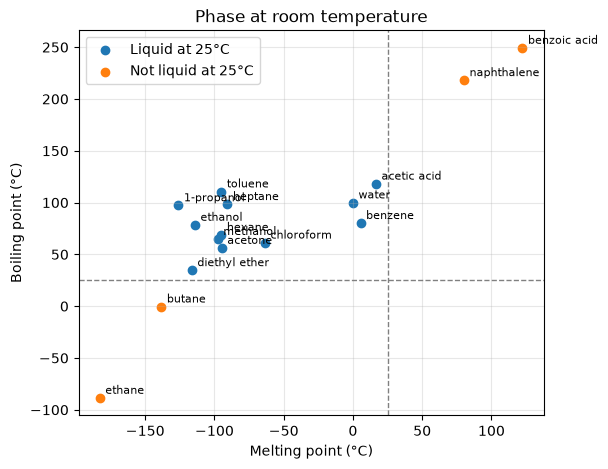

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    melting_point[is_liquid],
    boiling_point[is_liquid],
    label="Liquid at 25°C",
)
ax.scatter(
    melting_point[~is_liquid],
    boiling_point[~is_liquid],
    label="Not liquid at 25°C",
)

for name, melting, boiling in zip(compound_names, melting_point, boiling_point):
    ax.annotate(name, (melting, boiling), xytext=(4, 3), textcoords="offset points", fontsize=8)

ax.axvline(room_temperature_C, color="0.5", linestyle="--", linewidth=1)
ax.axhline(room_temperature_C, color="0.5", linestyle="--", linewidth=1)
ax.set_xlabel("Melting point (°C)")
ax.set_ylabel("Boiling point (°C)")
ax.set_title("Phase at room temperature")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


הגרף הזה פחות מנסה למצוא “חוק” כללי, ויותר עוזר לקרוא את הטבלה. הוא מראה את אותו תנאי שכתבנו בקוד: חומר נוזלי בטמפרטורת החדר אם נקודת ההתכה שלו נמוכה מ־`25°C` ונקודת הרתיחה שלו גבוהה מ־`25°C`.

כרגע התוצאה נמצאת רק במערך NumPy בשם `is_liquid`. אם נרצה להמשיך לעבוד עם התוצאה כחלק מהטבלה, למשל למיין, לסנן, להציג או לשמור אותה, כדאי להחזיר אותה ל־`DataFrame` כעמודה חדשה. כך כל תרכובת מקבלת גם את הסיווג שחישבנו עבורה.


In [7]:
df["liquid_at_25_C"] = is_liquid

display(df[["compound", "melting_point_C", "boiling_point_C", "liquid_at_25_C"]])


,compound,melting_point_C,boiling_point_C,liquid_at_25_C
0,water,0.0,100.0,True
1,methanol,-97.6,64.7,True
2,ethanol,-114.1,78.4,True
3,1-propanol,-126.0,97.2,True
4,acetone,-94.7,56.1,True
5,diethyl ether,-116.3,34.6,True
6,hexane,-95.0,68.7,True
7,heptane,-90.6,98.4,True
8,benzene,5.5,80.1,True
9,toluene,-95.0,110.6,True


כך מתקבל רצף עבודה נפוץ: Pandas לארגון הנתונים, NumPy לחישוב מספרי או לוגי, ו־Matplotlib להצגה גרפית של השאלה המדעית.
